## Dataset information

This dataset contains hourly energy usage data (PJME_MW) from 2002 to 2018. The task is to predict future energy consumption using this time series data.

## Types of Time Series Data

![](https://miro.medium.com/max/1400/1*V_RKPeIxCB9CS_2SsLyKXw.jpeg)

reference: https://engineering.99x.io/time-series-forecasting-in-machine-learning-3972f7a7a467

## Import modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error

## Data prep




In [2]:
df = pd.read_csv('PJME_hourly.csv')
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [3]:
df = df.set_index('Datetime')
df.sort_index(inplace=True)
df.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


In [4]:
df.index
# >> Note: Index is object type

Index(['2002-01-01 01:00:00', '2002-01-01 02:00:00', '2002-01-01 03:00:00',
       '2002-01-01 04:00:00', '2002-01-01 05:00:00', '2002-01-01 06:00:00',
       '2002-01-01 07:00:00', '2002-01-01 08:00:00', '2002-01-01 09:00:00',
       '2002-01-01 10:00:00',
       ...
       '2018-08-02 15:00:00', '2018-08-02 16:00:00', '2018-08-02 17:00:00',
       '2018-08-02 18:00:00', '2018-08-02 19:00:00', '2018-08-02 20:00:00',
       '2018-08-02 21:00:00', '2018-08-02 22:00:00', '2018-08-02 23:00:00',
       '2018-08-03 00:00:00'],
      dtype='object', name='Datetime', length=145366)

In [5]:
df.index = pd.to_datetime(df.index)

In [6]:
df.isnull().sum()

,0
PJME_MW,0


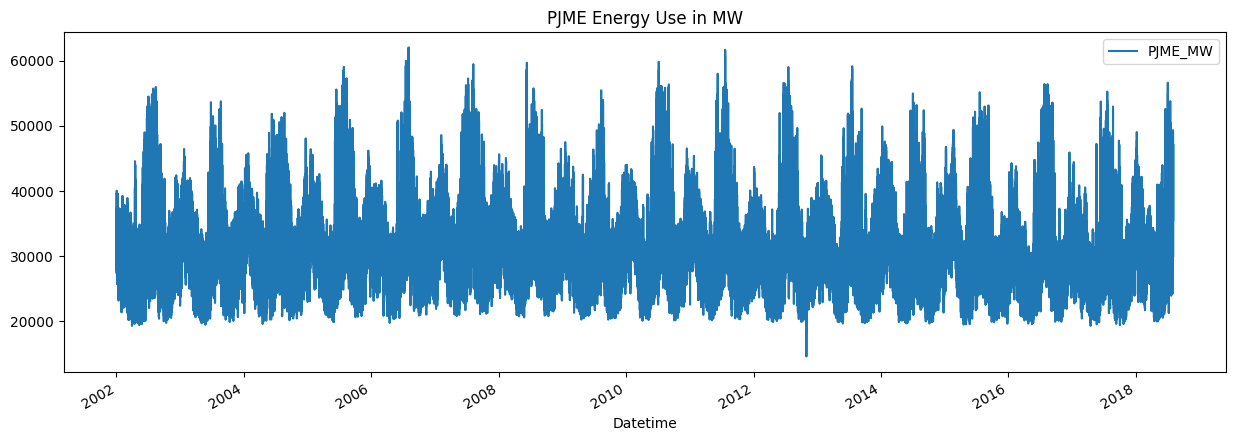

In [7]:
df.plot(figsize=(15, 5), title='PJME Energy Use in MW')
plt.show()

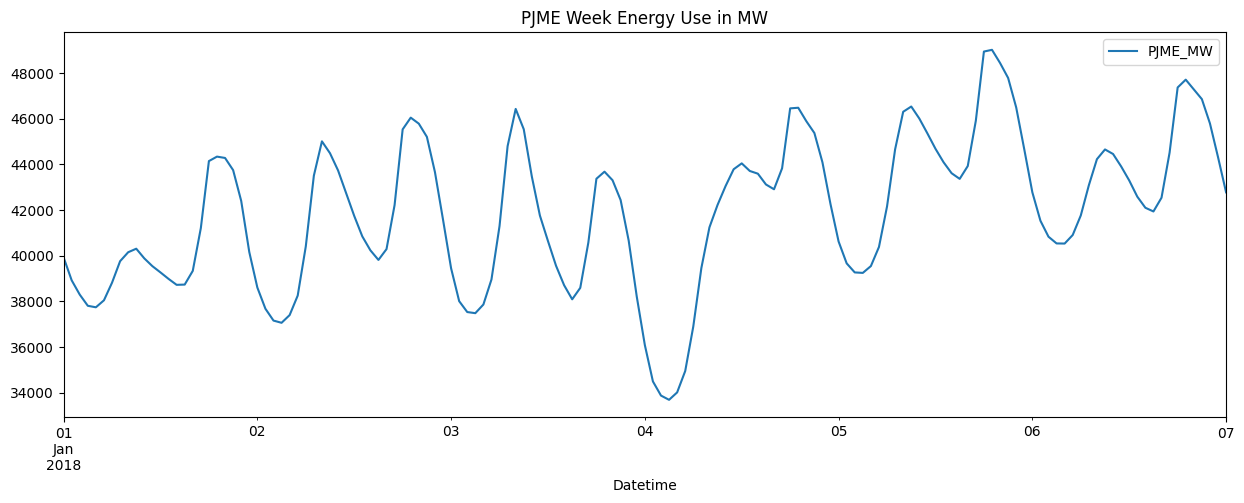

In [8]:
df.loc[(df.index >= '01-01-2018') & (df.index <= '01-07-2018')].plot(figsize=(15, 5), title='PJME Week Energy Use in MW')
plt.show()

## Feature creation

In [9]:
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['quarter'] = df.index.quarter
df['month'] = df.index.month
df['year'] = df.index.year
df['dayofyear'] = df.index.dayofyear
df['dayofmonth'] = df.index.day
df['weekofyear'] = df.index.isocalendar().week

df.head()

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
Datetime,,,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,2002,1,1,1
2002-01-01 02:00:00,29265.0,2,1,1,1,2002,1,1,1
2002-01-01 03:00:00,28357.0,3,1,1,1,2002,1,1,1
2002-01-01 04:00:00,27899.0,4,1,1,1,2002,1,1,1
2002-01-01 05:00:00,28057.0,5,1,1,1,2002,1,1,1


## Visualize feature / target relationship

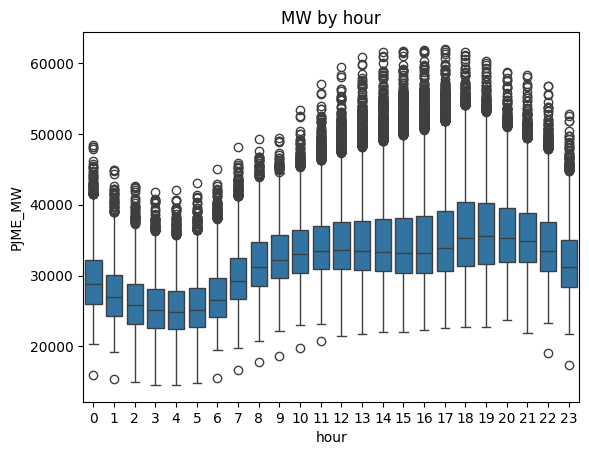

In [10]:
sns.boxplot(x='hour', y='PJME_MW', data=df)
plt.title('MW by hour')
plt.show()

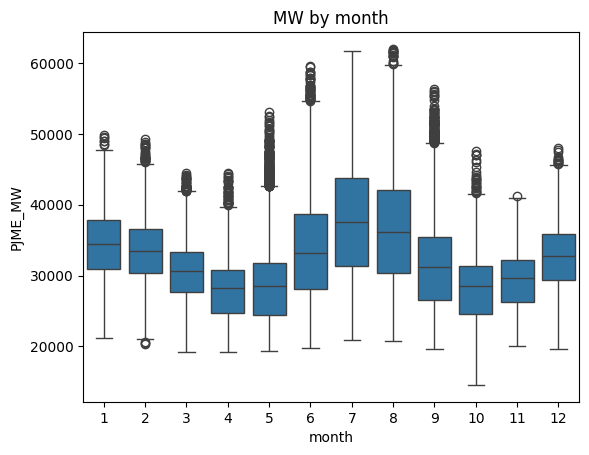

In [11]:
sns.boxplot(x='month', y='PJME_MW', data=df)
plt.title('MW by month')
plt.show()

## Train/test split

In [12]:
X = df.drop('PJME_MW', axis=1)
y = df['PJME_MW']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year']
X_train = X_train[FEATURES]
X_test = X_test[FEATURES]

## Create model

In [13]:
model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.01, early_stopping_rounds=50)
model.fit(X_train, y_train
          , eval_set=[(X_train, y_train), (X_test, y_test)]
          , verbose=100)

[0]	validation_0-rmse:6416.79588	validation_1-rmse:6433.11816
[100]	validation_0-rmse:3995.55257	validation_1-rmse:4012.74198
[200]	validation_0-rmse:3340.62755	validation_1-rmse:3356.72510
[300]	validation_0-rmse:3112.86329	validation_1-rmse:3132.75501
[400]	validation_0-rmse:2977.11776	validation_1-rmse:2999.51544
[500]	validation_0-rmse:2854.34224	validation_1-rmse:2878.46815
[600]	validation_0-rmse:2775.03256	validation_1-rmse:2800.40480
[700]	validation_0-rmse:2718.71719	validation_1-rmse:2744.88848
[800]	validation_0-rmse:2658.67905	validation_1-rmse:2686.13133
[900]	validation_0-rmse:2605.01328	validation_1-rmse:2633.68856
[999]	validation_0-rmse:2547.16408	validation_1-rmse:2577.51625


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

## Feature importance

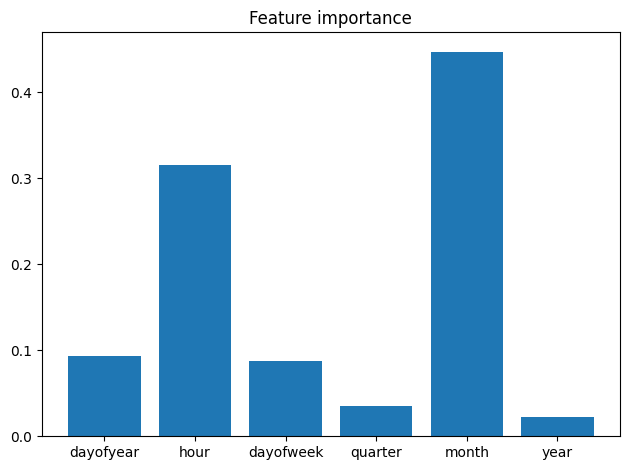

In [14]:
model.feature_importances_
plt.bar(FEATURES, model.feature_importances_)
plt.title('Feature importance')
plt.tight_layout()
plt.show()

In [15]:
pd.DataFrame(model.feature_importances_,
             index=model.feature_names_in_,
             columns=['importance']).sort_values(by='importance', ascending=False)

,importance
month,0.447030
hour,0.314791
dayofyear,0.093563
dayofweek,0.087175
quarter,0.035185
year,0.022256


# Forecast on test set

In [16]:
y_pred = model.predict(X_test)

compare = pd.DataFrame({'actual': y_test, 'prediction': y_pred}, index=X_test.index)
compare = compare.join(X_test[FEATURES])
compare.head()

,actual,prediction,dayofyear,hour,dayofweek,quarter,month,year
Datetime,,,,,,,,
2017-12-11 08:00:00,36021.0,34455.718750,345,8,0,4,12,2017
2008-08-13 20:00:00,40141.0,43905.933594,226,20,2,3,8,2008
2011-01-10 06:00:00,35201.0,32525.644531,10,6,0,1,1,2011
2003-12-09 23:00:00,34066.0,34273.656250,343,23,1,4,12,2003
2004-12-29 02:00:00,29686.0,27562.445312,364,2,2,4,12,2004


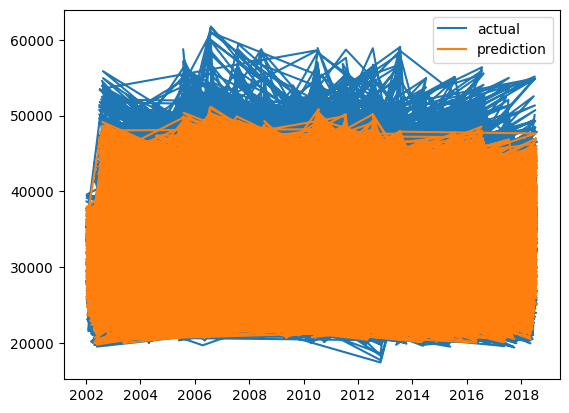

In [20]:
plt.plot(compare.index, compare['actual'], label='Actual')
plt.plot(compare.index, compare['prediction'], label='Prediction')
plt.legend()
plt.show()

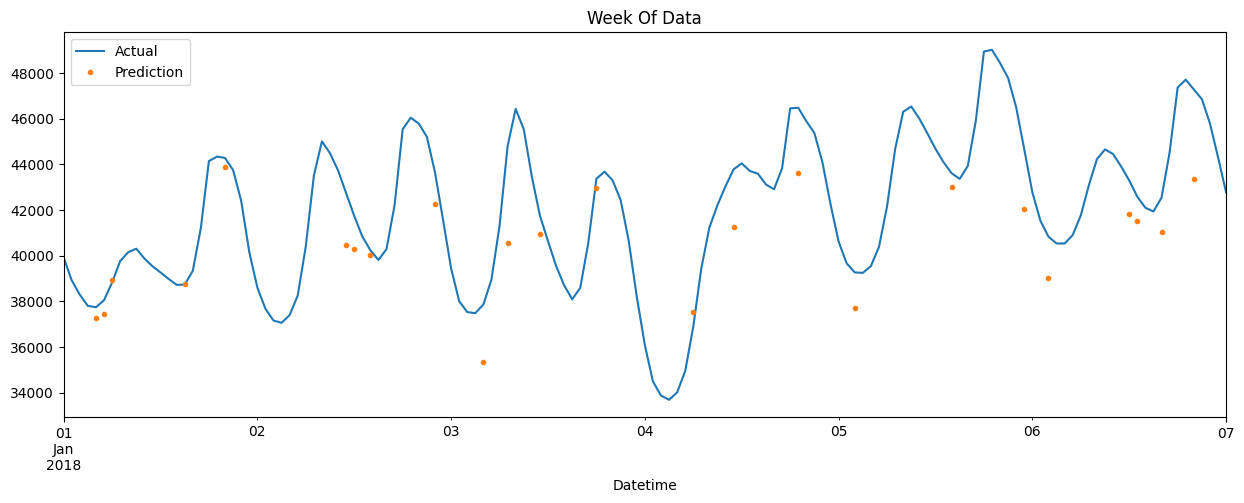

In [23]:
ax = df.loc[(df.index >= '01-01-2018') & (df.index <= '01-07-2018')]['PJME_MW'] \
    .plot(figsize=(15, 5), title='Week Of Data')
compare.loc[(compare.index >= '01-01-2018') & (compare.index <= '01-07-2018')]['prediction'] \
    .plot(ax=ax, style='.') # Plot on the same axes
plt.legend(['Actual','Prediction'])
plt.show()

## Evaluation

In [26]:
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

RMSE: 2577.52


### Next step:
* More robust cross validation
* Add more features (weather forecast, events, holidays...)